# **Лабораторная №1**

# Бизнес-задача
### Снижение оттока клиентов телекоммуникационной компании за счёт выявления факторов, влияющих на уход клиентов

## Гипотезы о факторах, влияющих на решение задачи:
- Тип контракта: Клиенты с помесячной оплатой уходят чаще, чем те, кто подписал контракт на 1–2 года.
- Длительность отношений: Клиенты с небольшим сроком обслуживания более склонны к оттоку, чем лояльные клиенты.
- Стоимость услуг: Высокая стоимость обслуживания может повышать вероятность ухода клиента, особенно при наличии более выгодных предложений на рынке.
- Дополнительные услуги: Отсутствие дополнительных сервисов повышает риск оттока.

## Необходимые данные:
Для проверки гипотез нам нужны:
- Демография (пол, пожилой возраст) -> позволяет выявить поведенческие различия между группами клиентов
- Параметры контракта (срок, способ оплаты, безбумажный чек) -> необходимо для анализа влияния условий обслуживания на отток
- Финансовые показатели (ежемесячный платеж, общая сумма) -> позволяет оценить влияние стоимости услуг
- Используемые услуги (тип интернета, дополнительные сервисы) -> помогает определить влияние уровня вовлеченности клиента

| Признак                                                                 | Тип данных        | Шкала измерения | Обоснование |
|-------------------------------------------------------------------------|------------------|-----------------|-------------|
| customerID                                                              | Текст            | Номинальная     | Уникальня метка потребителя. |
| gender                                                                  | Текст            | Номинальная     | Категории (Male/Female). |
| SeniorCitizen                                                           | Число (0/1)      | Номинальная     | Флаг (Да/Нет). |
| Partner, Dependents                                                     | Текст            | Номинальная     | Бинарные категории (Да/Нет). |
| tenure                                                                  | Число            | Относительная   | Срок лояльности клиента (есть абсолютный ноль) |
| PhoneService                                                            | Текст            | Номинальная     | Наличие услуги (Да/Нет). |
| MultipleLines                                                           | Текст            | Номинальная     | Наличие услуг (Yes, No, No phone service). |
| InternetService                                                         | Текст            | Номинальная     | Типы связи (DSL, Fiber optic, No). |
| OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | Текст | Номинальная | Наличие услуг (Да/Нет/No). |
| Contract                                                                | Текст            | Порядковая      |Иерархия по времени: Month-to-month < One year < Two year. |
| PaperlessBilling                                                        | Текст            | Номинальная     | Бинарные категории (Да/Нет). |
| PaymentMethod                                                           | Текст            | Номинальная     | Разные способы оплаты. |
| MonthlyCharges                                                          | Число            | Относительная   | Денежная величина. |
| TotalCharges                                                            | Число            | Относительная   | Суммарные затраты, абсолютный ноль возможен. |
| Churn                                                                   | Текст            | Номинальная     | Целевой признак (ушел/остался). |

In [98]:
import pandas as pd
import numpy as np

## Загрузка данных

In [99]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

Общая информация о датасете

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Пропуски

In [101]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Дубликаты строк

In [102]:
df.duplicated().sum()

np.int64(0)

Уникальные значения в колонках

In [103]:
df.nunique().sort_values(ascending=False)

customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
StreamingMovies        3
TechSupport            3
OnlineBackup           3
StreamingTV            3
DeviceProtection       3
MultipleLines          3
InternetService        3
OnlineSecurity         3
Contract               3
Partner                2
SeniorCitizen          2
gender                 2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
dtype: int64

## Очистка данных

Удаление не нужных столбцов

In [104]:
df.drop('customerID', axis=1, inplace=True)

Исправление типа данных

In [105]:
target = 'Churn' # целевая переменная
target_map = {'No': 0, 'Yes': 1}
df[target] = df[target].map(target_map).astype(int)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Обработка скрытых пропусков

In [106]:
df['TotalCharges'].isnull().sum()

np.int64(11)

Заполнение пропусков нулями

In [107]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

## Масштабирование признаков

In [108]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [109]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_standardized = df.copy()
df_normalized = df.copy()

# Стандартизация
std_scaler = StandardScaler()
df_standardized[num_cols] = std_scaler.fit_transform(df[num_cols])

# Нормализация
min_max_scaler = MinMaxScaler()
df_normalized[num_cols] = min_max_scaler.fit_transform(df[num_cols])

print("Стандартизированные данные:")
print(df_standardized[num_cols].head(3))
print()
print("Нормализованные данные:")
print(df_normalized[num_cols].head(3))

Стандартизированные данные:
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674

Нормализованные данные:
     tenure  MonthlyCharges  TotalCharges
0  0.013889        0.115423      0.001275
1  0.472222        0.385075      0.215867
2  0.027778        0.354229      0.010310


## Кодирование категориальных признаков

In [110]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [111]:
le = LabelEncoder()
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']

for col in binary_cols:
    df_standardized[col] = le.fit_transform(df_standardized[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'PaymentMethod']
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df_standardized[multi_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(multi_cols),
    index=df_standardized.index
)
df_standardized = df_standardized.drop(columns=multi_cols)
df_final = pd.concat([df_standardized, encoded_df], axis=1)
# df_final = pd.get_dummies(df_standardized, columns=multi_cols, drop_first=True)
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_final['Contract'] = df_final['Contract'].map(contract_map)
bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)
print(df_final.head(3))
df_final.columns

   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0 -1.277445             0   
1       1              0        0           0  0.066327             1   
2       1              0        0           0 -1.236724             1   

   Contract  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0         0                 1       -1.160323     -0.994242  ...   
1         1                 0       -0.259629     -0.173244  ...   
2         0                 1       -0.362660     -0.959674  ...   

   DeviceProtection_Yes  TechSupport_No internet service  TechSupport_Yes  \
0                   0.0                              0.0              0.0   
1                   1.0                              0.0              0.0   
2                   0.0                              0.0              0.0   

   StreamingTV_No internet service  StreamingTV_Yes  \
0                              0.0              0.0   
1              

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'Contract', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

## Выводы

### Выводы по работе
**1. Основной результат**

В ходе работы был очищен и предобработан набор данных, готовый для дальнейшего анализа и обучения моделей классификации оттока. Исходные 20 разнородных признаков были преобразованы в 30 числовых векторов, которые учитывают как демографию, так и поведение клиентов.

**2. Детализация**

Проведен первичный анализ данных:
- Удален неинформативный идентификатор customerID
- Выявлены пустые пропуски в TotalCharges. Поскольку они соответствовали новым клиентам (tenure=0), их заполнение позволило сохранить целостность данных без удаления важных строк
Выполнено преобразование признаков:
- Числовые признаки приведены к единой шкале с использованием стандартизации и нормализации
- Кодирование:
    - One-Hot Encoding для номинальных признаков
    - Manual Mapping для Contract (0, 1, 2) — чтобы сохранить логику «чем дольше контракт, тем стабильнее клиент»
    - Label Encoding для категориальных признаков
    - Целевая переменная Churn преобразована в бинарный формат

**3. Связь с предыдущими частями**

Полученный датасет напрямую соответствует поставленной бизнес-задаче и позволяет проверить выдвинутые гипотезы о влиянии различных факторов (контракт, стоимость, услуги и др.) на отток клиентов.

In [112]:
# le = LabelEncoder()
# binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender', 'SeniorCitizen']
# for col in binary_cols:
#     df[col] = le.fit_transform(df[col])

# contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
# df['Contract'] = df['Contract'].map(contract_map)

# multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
#               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
#               'PaymentMethod']
# df_final = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# scaler = StandardScaler()

# target = df_final['Churn']
# features = df_final.drop('Churn', axis=1)

# df_scaled_values = scaler.fit_transform(features)

# df_final_unified = pd.DataFrame(df_scaled_values, columns=features.columns)
# df_final_unified['Churn'] = target.values

# print(df_final_unified.head())

# **Лабораторная №2**

# 1. Анализ распределения признаков

In [113]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Числовые признаки

### Гистограммы и графики плотности для числовых признаков

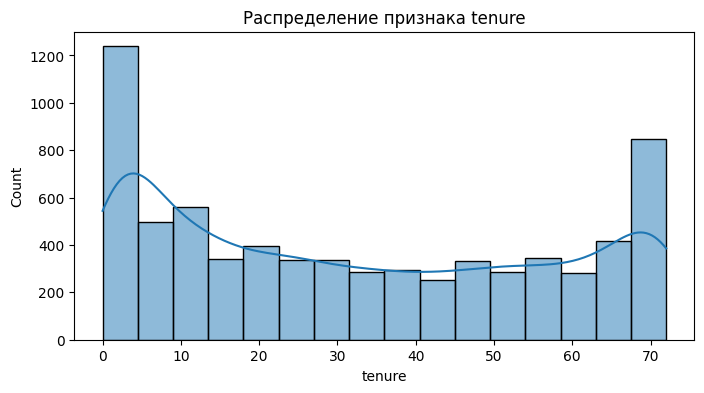

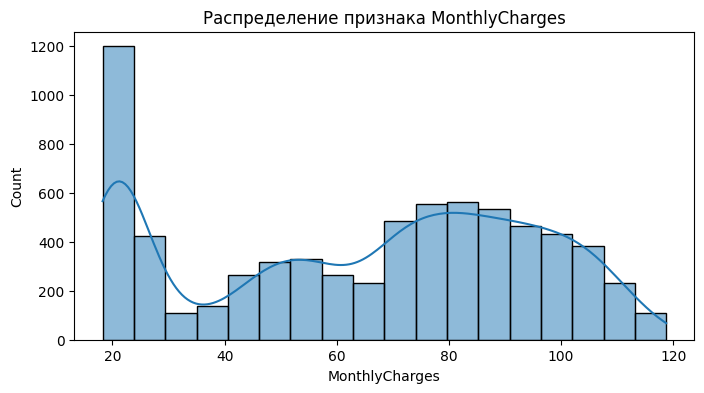

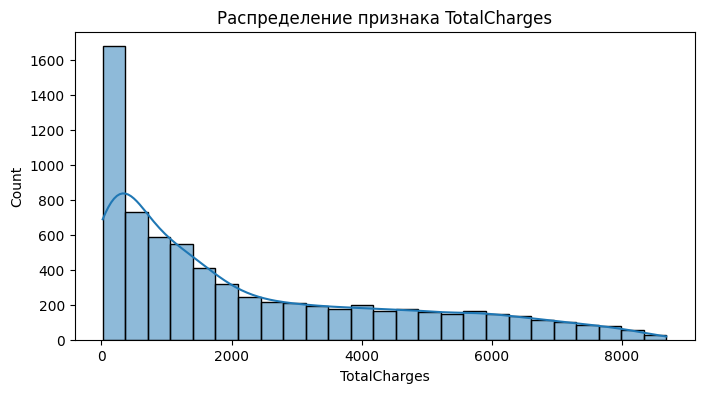

In [114]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение признака {col}')
    plt.show()

### Поиск выбросов

Вывод по выбросам:

- В tenure выбросы минимальны.

- В MonthlyCharges есть выброс - преобладают клиенты с минимальной ценой тарифа.

- В TotalCharges есть выброс - преобладают клиенты с долгим обслуживанием.

### Диаграмма "ящик с усами" для числовых признаков

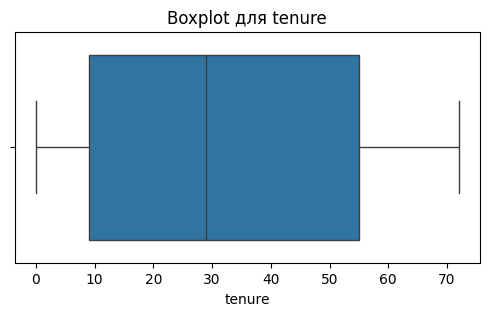

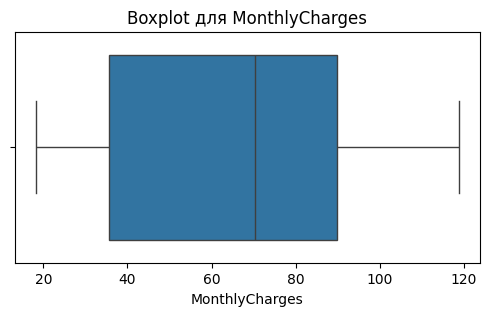

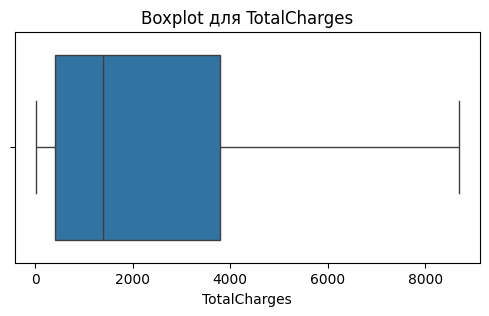

In [115]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot для {col}')
    plt.show()

## 1.2 Категориальные признаки

C:\Users\HONOR\AppData\Local\Temp\ipykernel_22676\595124287.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


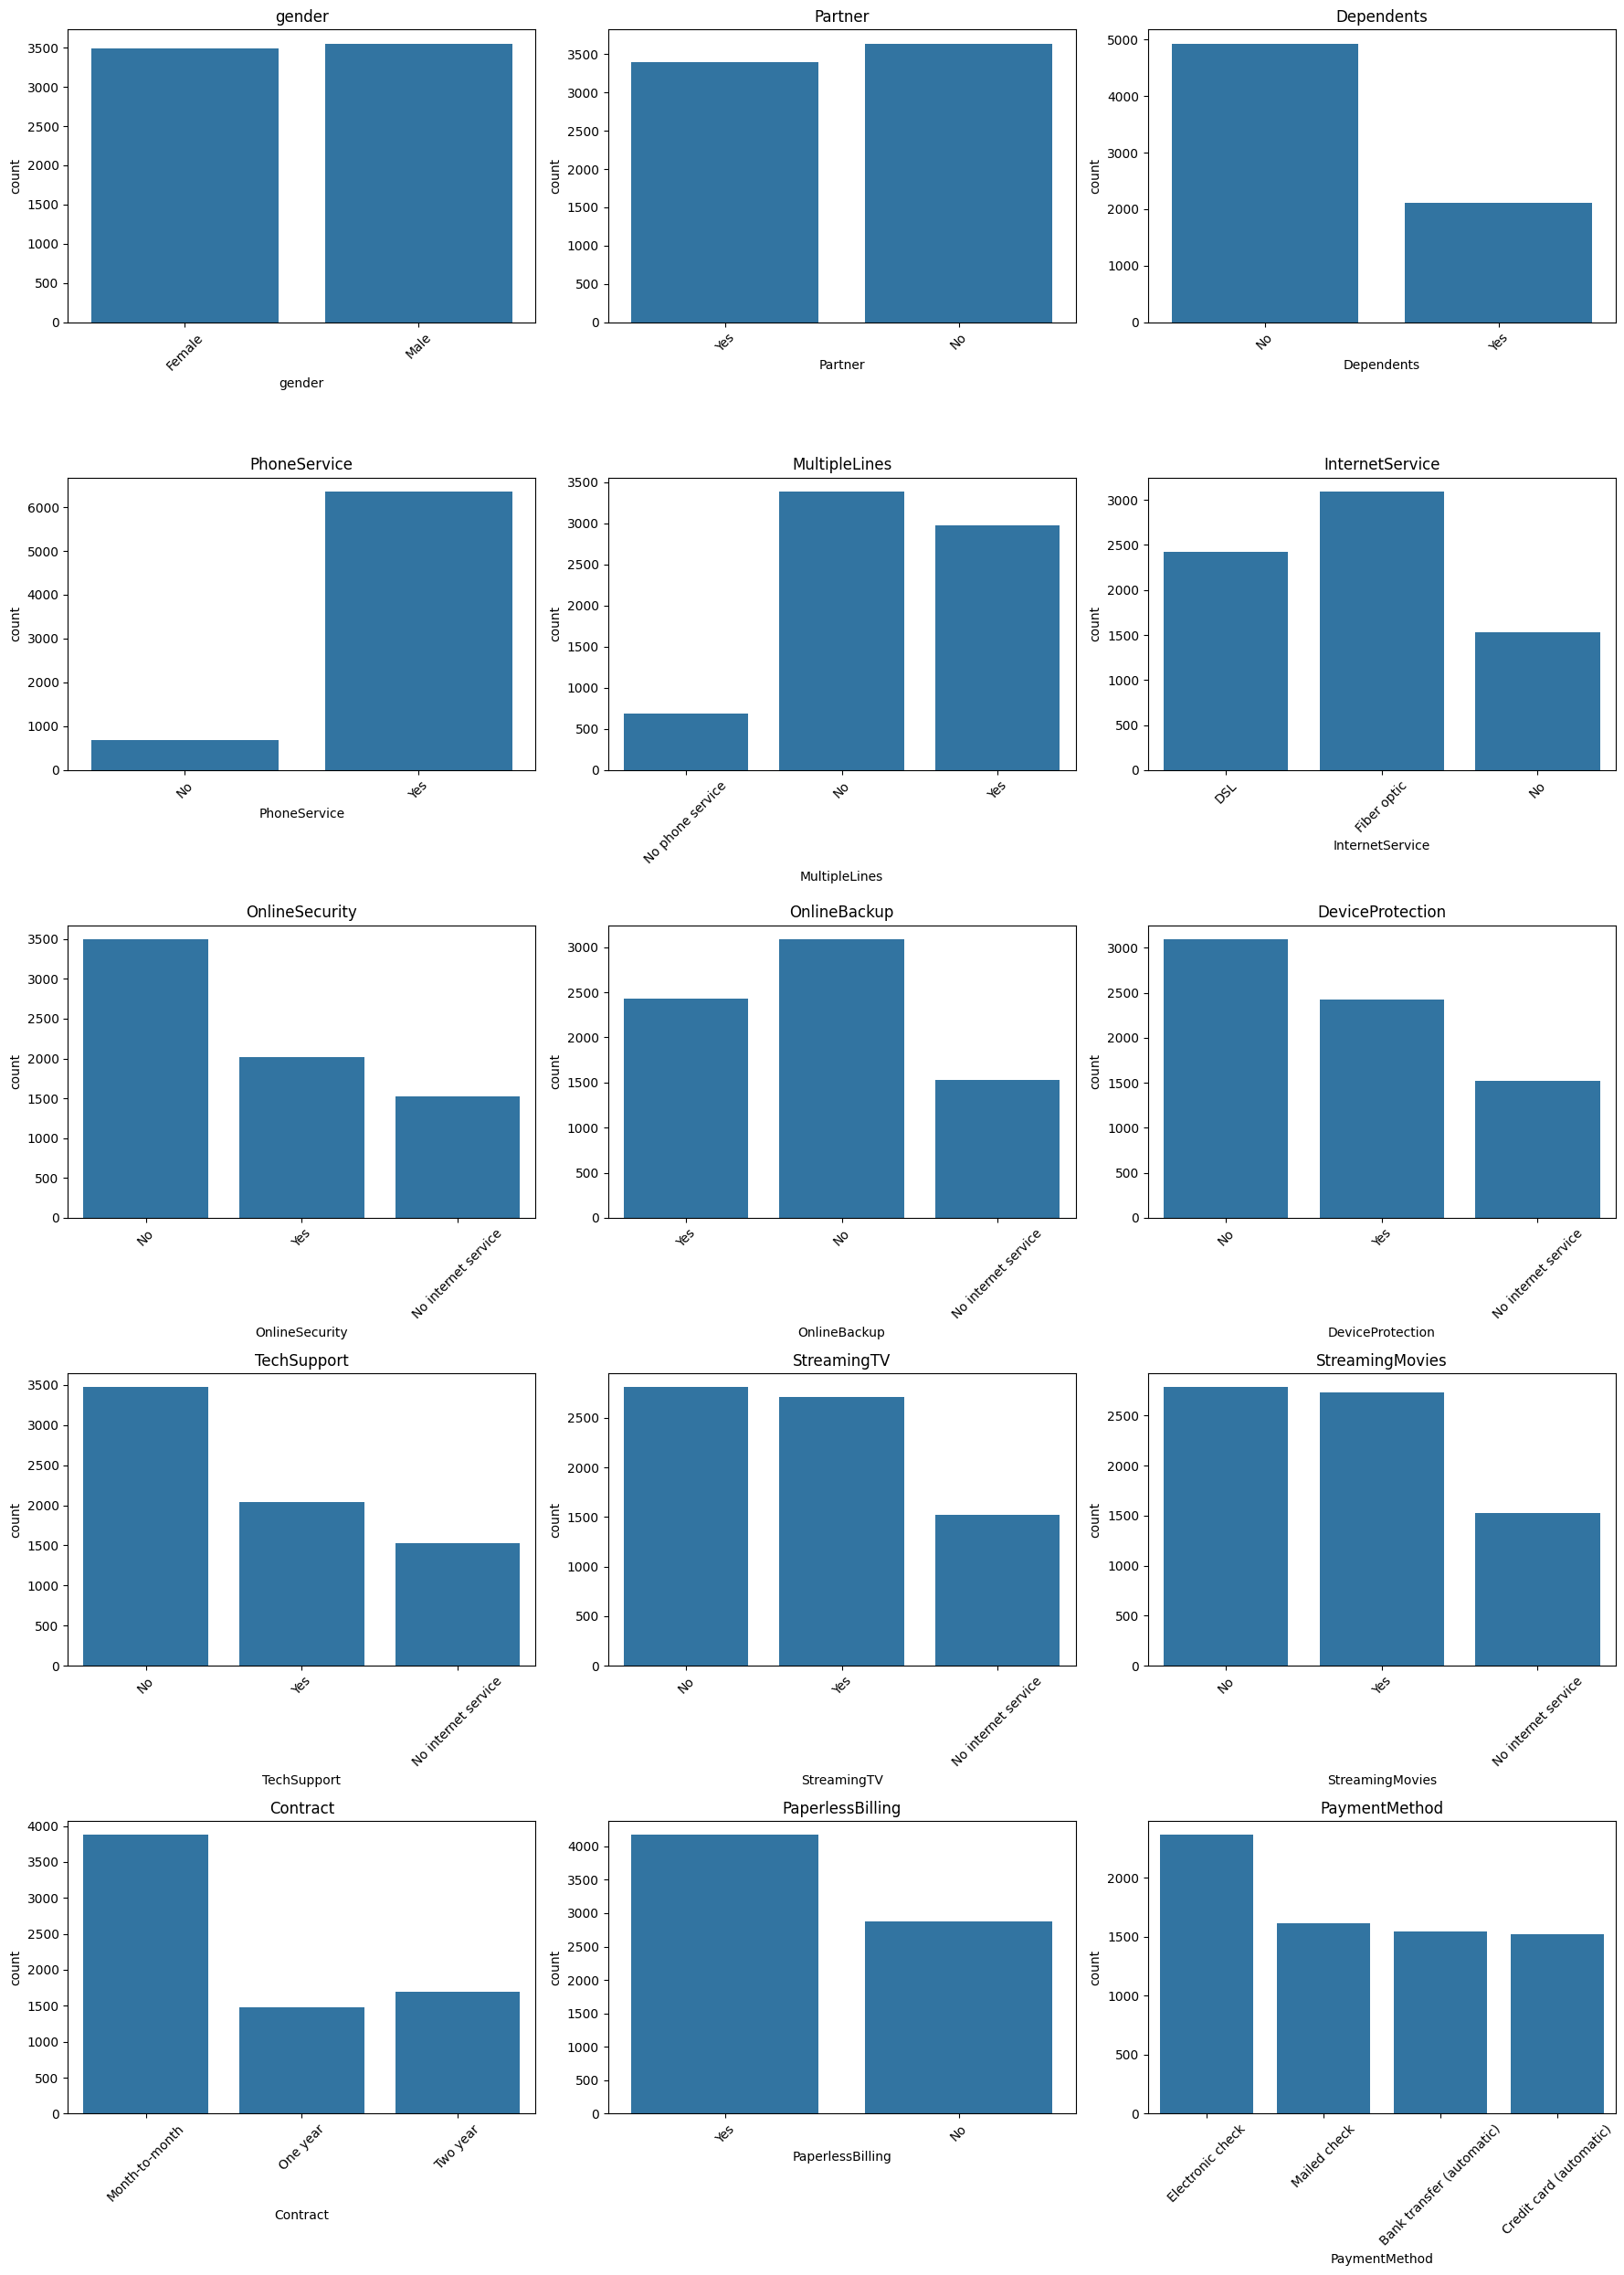

In [116]:
cat_cols = df.select_dtypes(include='object').columns
# print(cat_cols)

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Оценка распределения категорий

Наблюдается выраженный дисбаланс в ряде категориальных признаков. Наиболее заметные перекосы присутствуют в признаках Contract, InternetService и дополнительных сервисах (OnlineSecurity, TechSupport и др.), где преобладают отдельные категории.

В то же время такие признаки как gender и MultipleLines имеют более равномерное распределение категорий.

Обнаруженные дисбалансы могут указывать на различия в поведении клиентов и потенциально влиять на вероятность оттока.

## 2. Анализ взаимосвязей между признаками

### Матрица корреляции

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0          0              0        1           0 -1.277445             0   
1          1              0        0           0  0.066327             1   
2          1              0        0           0 -1.236724             1   
3          1              0        0           0  0.514251             0   
4          0              0        0           0 -1.236724             1   
...      ...            ...      ...         ...       ...           ...   
7038       1              0        1           1 -0.340876             1   
7039       0              0        1           1  1.613701             1   
7040       0              0        1           1 -0.870241             0   
7041       1              1        1           0 -1.155283             1   
7042       1              0        0           0  1.369379             1   

      Contract  PaperlessBilling  MonthlyCharges  TotalCharges  ...  \
0            0  

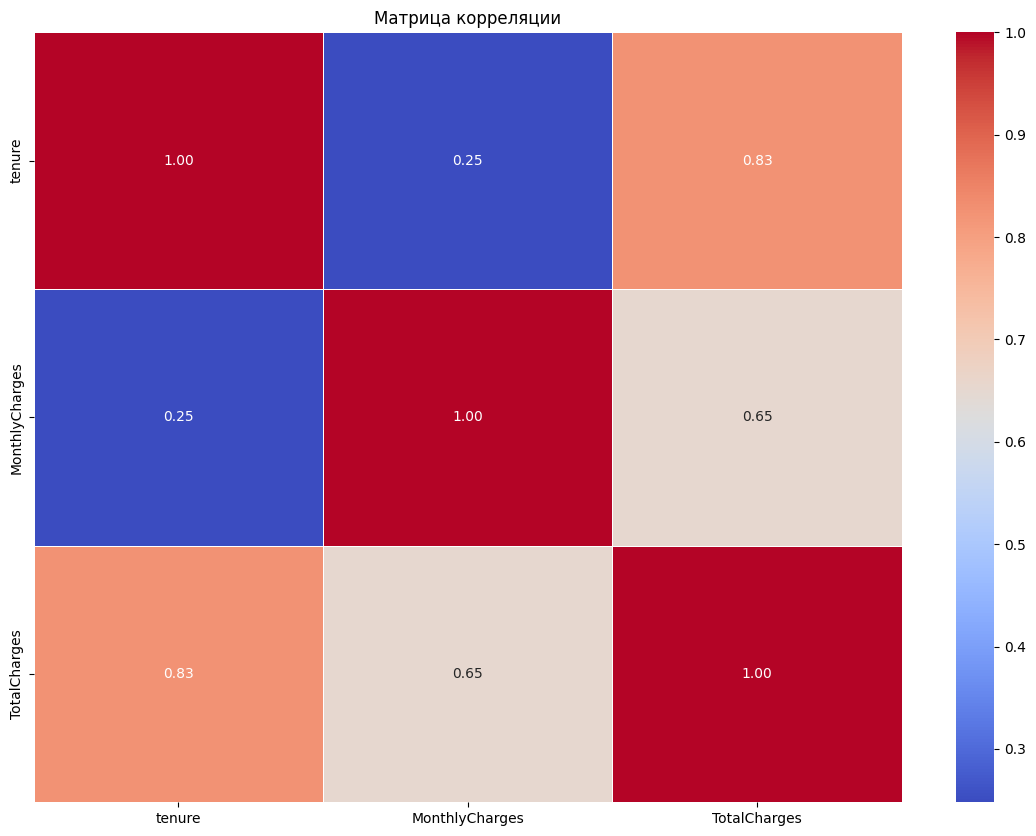

In [117]:
plt.figure(figsize=(14,10))
print(df_final)
cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = df_final[cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.title('Матрица корреляции')
plt.show()

### Пары признаков с высокой корреляцией

In [118]:
# берем только верхний треугольник матрицы
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# ищем корреляции выше порога
high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if abs(upper.loc[row, col]) > 0.6]

high_corr.sort(key=lambda x: abs(x[2]))
print(high_corr)
# high_corr

[('TotalCharges', 'MonthlyCharges', np.float64(0.6508643497230399)), ('TotalCharges', 'tenure', np.float64(0.8254640864073006))]


1. tenure vs TotalCharges

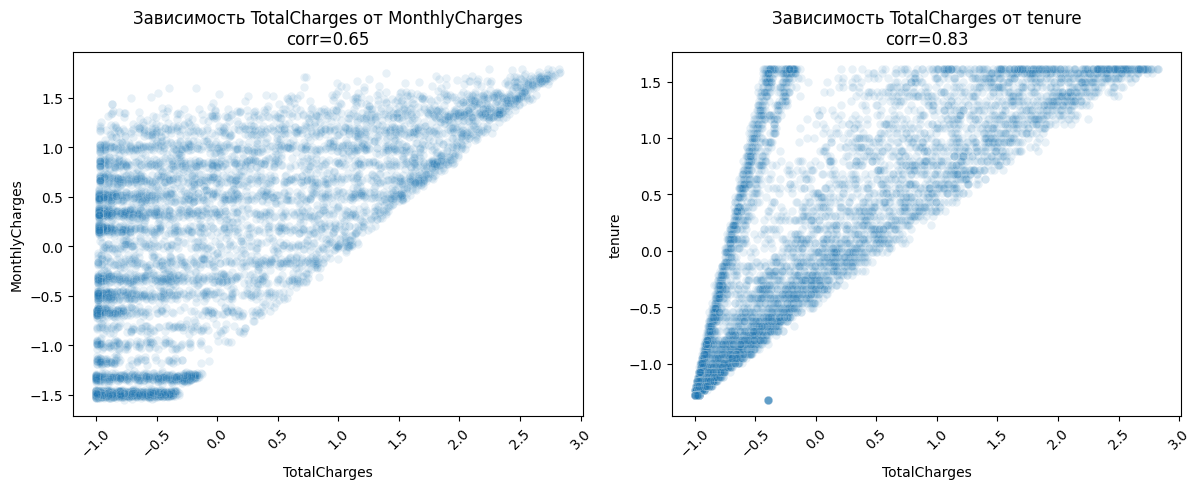

In [119]:
filtered_corr = [(c1, c2, corr) for c1, c2, corr in high_corr if abs(corr) < 0.999]

n_cols = 3
n_rows = math.ceil(len(filtered_corr) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, (col1, col2, corr) in enumerate(filtered_corr):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(data=df_final, x=col1, y=col2, alpha=0.1)
    plt.title(f'Зависимость {col1} от {col2}\ncorr={corr:.2f}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Основные выводы на основе EDA

**1) Вывод по гитограммам**

**Основной вывод**: Распределения числовых признаков являются неоднородными, с выраженной асимметрией и наличием нескольких характерных групп значений.

**Детализация**:
- tenure:
    - Биомодальное распределение
    - Преобладают 2 группы клиентов (новые и долгосрочные)

- MonthlyCharges:
    - Распределение скошено вправо
    - Несколько локальных пиков, обусловленных тарифными пакетами

- TotalCharges:
   - Распределение скошено вправо
   - Преобладают клиенты с низкими суммарными затратами

**Связь с исследованием**: Результаты подтверждают наличие различных типов клиентов по длительности обслуживания и уровню затрат, что важно для анализа оттока.

**2) Вывод по диаграммам "ящик с усами"**

**Основной вывод**: Выбросы выражены слабо, однако наблюдается значительный разброс значений в зависимости от типа признака.

**Детализация**:
- Для tenure без выраженных выбросов

- Для MonthlyCharges наблюдается смещение в сторону более высоких ежемесячных платежей, что отражает преобладание высокотарифных клиентов

- Для TotalCharges большая часть клиентов с небольшим накопленным стажем

**Связь с исследованием**: Результаты подтверждают неоднородность клиентской базы по уровню использования услуг.

**3) Выводы по категориальным признакам**

**Основной вывод**: В данных присутствует выраженный дисбаланс категорий и неоднородное распределение сервисов.

**Детализация**:
- В большинстве признаков наблюдается дисбаланс категорий, например:
    - клиенты чаще используют Month-to-month контракт
    - чаще встречается Electronic check как способ оплаты

- Услуги (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) распределены неравномерно

**Связь с исследованием**: Результаты указывают на различия в уровне вовлечённости клиентов может быть связано с риском оттока.

**4) **Выводы по коррелируемым признакам**

- Сильная положительная связь между TotalCharges и tenure (≈ 0.83), что логично, так как суммарные расходы клиента напрямую зависят от длительности обслуживания

- Низкая корреляция прослеживается между tenure и MonthlyCharges, что означает независимость этих признаков.

**Связь с исследованием**: Результаты  подтверждают наличие избыточного признака TotalCharges, который может не влиять на целевую переменную. Его наличие может привести к мультиколлиниарности и дальнейшему дообучению модели. Его следует убрать либо сделать комбинированную переменную на основе tenure и MonthlyCharges.

### **Общий вывод**
EDA показал, что поведение клиентов сильно связано с типом контракта, длительностью обслуживания, уровнем ежемесячных платежей, а также большая часть признаков имеет структурную зависимость, обусловленную логикой предоставления услуг. При этом часть демографических признаков имеет слабую информативность.

Также в данных присутствует избыточность признаков.

## 4. Закономерности, аномалии и взаимосвязи в данных

**Закономерности**
* Поведение клиентов связано с типом контракта и длительностью обслуживания: клиенты с долгосрочными контрактами и большим tenure реже подвержены оттоку.
* Более высокие значения MonthlyCharges характерны для клиентов с определённым типом интернет-сервиса.
* TotalCharges закономерно увеличивается с ростом tenure, что отражает накопительный характер платежей.

**Взаимосвязи**
* Сильная положительная связь между tenure и TotalCharges (≈ 0.83).
* Зависимость MonthlyCharges от типа интернет-сервиса:
    - Fiber optic → выше платежи
    - No internet → ниже платежи
* Наблюдаются логические связи между бинарными признаками после кодирования (например, PhoneService и MultipleLines_No phone service).

**Аномалии**
* Признаки вида “No internet service” образуют почти идеальные корреляции (≈ 1), что является не статистической, а логической зависимостью.
* После one-hot encoding присутствуют избыточные признаки, дублирующие одну и ту же информацию.

## 5. Рекомендации по подготовке данных к моделированию

**Удаление избыточных и дублирующих признаков**

- Признаки, имеющие корреляцию ≈ 1 или -1, возможно следует удалить, так как они:
    - не добавляют новой информации
    - могут ухудшить качество модели
- В частности:
    - признаки вида "No internet service" дублируют InternetService_No
    - признаки, связанные с отсутствием телефонной связи, дублируют PhoneService
- Возможное удаление gender, так как он не показывает значимой связи с другими признаками и, вероятно, с целевой переменной.

## 6. Гипотезы для дальнейшего исследования

**1. Гипотеза о роли дополнительных услуг**

Клиенты, не использующие дополнительные сервисы (OnlineSecurity, TechSupport и др.), более склонны к оттоку.

**2. Гипотеза о влиянии способа оплаты**

Использование Electronic check связано с более высоким уровнем оттока по сравнению с автоматическими способами оплаты.

**3. Гипотеза о влиянии наличия иждивенца**

Клиенты, имеющие иждивенцев, с меньшей вероятностью склонны к оттоку по сравнению с клиентами без иждивенцев.